In [2]:
%pip install crunch-cli --upgrade --quiet --progress-bar off
!crunch setup-notebook structural-break-real-time sVHg3JzIvGqSJxXwZPW8oOab

Note: you may need to restart the kernel to use updated packages.
crunch-cli, version 12.0.1
delete c:\Private Chance\breakdown\files\.crunchdao
you appear to have never submitted code before
data\X_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_train.parquet (218514418 bytes)
data\X_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_test.reduced.parquet (2587435 bytes)
data\y_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_train.parquet (8356193 bytes)
data\y_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_test.reduced.parquet (106299 bytes)
data\y_test_index.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_test_index.reduced.pa


  0%|          | 0.00/219M [00:00<?, ?iB/s]
  0%|          | 131k/219M [00:00<03:04, 1.18MiB/s]
  0%|          | 262k/219M [00:00<03:07, 1.17MiB/s]
  0%|          | 524k/219M [00:00<02:02, 1.77MiB/s]
  0%|          | 934k/219M [00:00<01:22, 2.64MiB/s]
  1%|          | 1.64M/219M [00:00<00:51, 4.17MiB/s]
  1%|          | 2.56M/219M [00:00<00:37, 5.71MiB/s]
  2%|▏         | 4.16M/219M [00:00<00:23, 8.96MiB/s]
  2%|▏         | 5.08M/219M [00:00<00:25, 8.29MiB/s]
  3%|▎         | 6.47M/219M [00:00<00:21, 9.84MiB/s]
  4%|▍         | 8.29M/219M [00:01<00:17, 12.0MiB/s]
  5%|▍         | 10.2M/219M [00:01<00:14, 14.0MiB/s]
  6%|▌         | 12.0M/219M [00:01<00:13, 15.0MiB/s]
  6%|▌         | 13.5M/219M [00:01<00:13, 14.7MiB/s]
  7%|▋         | 15.2M/219M [00:01<00:13, 15.0MiB/s]
  8%|▊         | 16.7M/219M [00:01<00:14, 14.3MiB/s]
  8%|▊         | 18.3M/219M [00:01<00:13, 14.7MiB/s]
  9%|▉         | 19.8M/219M [00:01<00:13, 14.3MiB/s]
 10%|▉         | 21.3M/219M [00:01<00:15, 12.6MiB/s]
 10%|

In [3]:
import math
import os
from typing import Iterable, List, Optional, Tuple

# Import your dependencies.
import joblib
import numpy as np
import pandas as pd
import pywt
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.stats import ks_2samp, skew
from scipy.signal import welch

In [4]:
import crunch

# Load the Crunch Toolings (data loader, local tester, submitter).
crunch_tools = crunch.load_notebook()

c:\Private Chance\breakdown\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded crunch tools for module: <module '__main__'>

cli version: 12.0.1
available ram: 15.76 gb
available cpu: 8 core
----


In [5]:
train_data, test_data = crunch_tools.load_data()

data\X_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_train.parquet (218514418 bytes)
data\X_train.parquet: already exists, file length match
data\X_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_test.reduced.parquet (2587435 bytes)
data\X_test.reduced.parquet: already exists, file length match
data\y_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_train.parquet (8356193 bytes)
data\y_train.parquet: already exists, file length match
data\y_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_test.reduced.parquet (106299 bytes)
data\y_test.reduced.parquet: already exists, file length match
data\y_test_index.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws

In [ ]:
for dataset_id, x_hist, x_online, tau in train_data:
    if tau is not None and 50 <= tau <= len(x_online) - 50:
        break

x_hist   = np.asarray(x_hist)
x_online = np.asarray(x_online)

print(f"      series id: {dataset_id}")
print(f"historical size: {len(x_hist)}")
print(f"    online size: {len(x_online)}")
print(f"   break at tau: {tau}   (None means no break)")

In [6]:
len(train_data)

10000

In [ ]:
train_data = train_data[:100]



100

In [ ]:
!pip install statsmodels

In [29]:
# len(train_data[0][0])
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(time_series_data, model='multiplicative')
trend    = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

ValueError: Multiplicative seasonality is not appropriate for zero and negative values

In [12]:
from scipy.fft import fft, fftfreq

In [ ]:
temp_data = list(train_data[0][1]) + list(train_data[0][2])

temp_data


1608

In [ ]:
time_series_data = temp_data

1608

In [ ]:
fft_values = fft(time_sereis_data)
frequencies = fftfreq*N, 

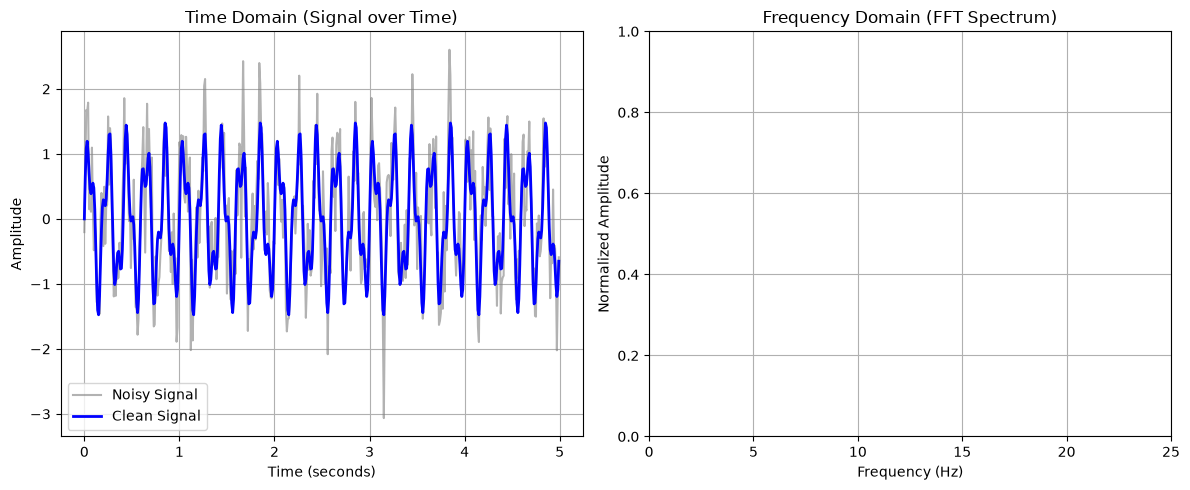

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# 1. Generate a dummy time series signal
sample_rate = 100  # Data points per second (Hz)
duration = 5       # Duration in seconds
N = sample_rate * duration  # Total samples

t = np.linspace(0, duration, N, endpoint=False)

# Signal = 5 Hz wave + 12 Hz wave + Random noise
pure_signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 12 * t)
noise = np.random.normal(0, 0.5, N)
time_series_data = pure_signal + noise

# 2. Compute the Fast Fourier Transform (FFT)
fft_values = fft(time_series_data)
frequencies = fftfreq(N, 1 / sample_rate)

# Extract positive frequencies and normalize amplitude
positive_frequencies = frequencies[:N // 2]
amplitudes = (2.0 / N) * np.abs(fft_values[:N // 2])

# 3. Plot the Results
plt.figure(figsize=(12, 5))

# Plot 1: Time Domain (Original Signal)
plt.subplot(1, 2, 1)
plt.plot(t, time_series_data, color='gray', alpha=0.6, label='Noisy Signal')
plt.plot(t, pure_signal, color='blue', label='Clean Signal', linewidth=2)
plt.title('Time Domain (Signal over Time)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# Plot 2: Frequency Domain (FFT Spectrum)
plt.subplot(1, 2, 2)
# plt.stem(positive_frequencies, amplitudes, use_line_collection=True, linefmt='r-', markerfmt='ro', basefmt=' ')
plt.title('Frequency Domain (FFT Spectrum)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Amplitude')
plt.xlim(0, 25)  # Zooming in on relevant frequencies
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# for dataset_id, x_hist, x_online. tau in train_data:
#     if data_counter == 100 and data_t = data_nt:
#         break
